# BERT Reranker, example mixed-length workload: trn2.3xlarge, trace, LNC=1

[Alibaba-NLP/gte-multilingual-reranker-base](https://huggingface.co/Alibaba-NLP/gte-multilingual-reranker-base)
behind NVIDIA Triton Inference Server, benchmarked with an **example mixed-length workload**
rather than a fixed sequence length.

**Path**: `torch_neuronx.trace()` (deprecated, SDK 2.31 only) | **dtype**: full BF16 | **Triton model instances**: 8 (one per NeuronCore, each holding every length)

## The example workload

An illustrative workload, in round numbers, shaped like a typical search reranker: mostly short
query+passage pairs sent in large batches. Five length buckets; the client groups each request's
sequences by length and sends one Triton call per bucket, up to 32 sequences per call.

| bucket | % Triton calls | mean sequences per call | % sequences (derived) | % compute (derived) |
|---:|---:|---:|---:|---:|
| 128 | 30 | 6 | 10.9 | 5.5 |
| 256 | 50 | 28 | 84.8 | 85.2 |
| 512 | 15 | 4 | 3.6 | 7.3 |
| 768 | 3 | 2 | 0.4 | 1.1 |
| 1024 | 2 | 2 | 0.2 | 1.0 |

Call sizes are drawn per bucket from a distribution with that mean. **To model your own traffic,
edit `EXAMPLE_MIX` in Step 5** and re-run; the bucket sets in Step 1 may then also need revisiting.

## What gets compiled

Sparse batch buckets per length, chosen from the call-size distribution. A call is routed to the
smallest compiled batch that fits it.

| length | PyTorch Native (24 graphs) | trace (12 graphs) |
|---:|---|---|
| 128 | 1, 4, 8, 16, 32 | 8, 32 |
| 256 | 8, 16, 24, 32 | 24, 28, 32 |
| 512 | 2, 4, 8, 16, 32 | 4, 8, 32 |
| 768 | 1, 2, 4, 8, 32 | 4, 32 |
| 1024 | 1, 2, 4, 8, 32 | 4, 32 |

**Why trace gets fewer graphs:** `torch_neuronx.trace` embeds the model weights in every compiled
graph (~0.75 GB each), so per-core device memory caps how many can be loaded. On inf2 (16 GB per
NeuronCore) loading failed at about 18 graphs. PyTorch Native keeps one copy of the weights shared
by all its graphs, so all 24 fit. The 12-graph trace set was chosen to minimise padded compute for
the example workload: padded compute is 1.15x the real compute, versus 1.13x for the 24-graph set.

## What gets measured

1. **Throughput vs latency**: a closed-loop sweep over client concurrency on gRPC. Each point gives
   sequences/s and call latency p50/p90/p99. Plotted and saved as JSON.
2. **Batching at seq=256**: sequences/s vs batch size with one call in flight, for the bucket that
   carries most of the compute in this example.


---
## Step 0: Environment

Every step that touches the Neuron device runs in a subprocess or container, never in this kernel:
a process that initialises the Neuron runtime keeps its cores until it exits.


In [1]:
import os, subprocess, sys, time, json, shutil, math, random

def sh(cmd, **kw):
    r = subprocess.run(cmd, shell=isinstance(cmd, str), capture_output=True, text=True, **kw)
    return r.stdout.strip(), r.stderr.strip(), r.returncode

PLATFORM, PATH, LNC = "trn2", "trace", "1"
DEV = "trn2"
TAG = "trn2_trace_lnc1"
NUM_INSTANCES = 8
BETA4 = "421672808698.dkr.ecr.us-east-1.amazonaws.com/concourse-release-0461d3b:2.13.0-neuronx-py312-sdk2.32.0-ubuntu24.04-neurondlcbuilder-development-6516808413-0"
TRACE_BASE = "public.ecr.aws/neuron/pytorch-inference-neuronx:2.9.0-neuronx-py312-sdk2.31.0-ubuntu24.04"
MODEL_ID = "Alibaba-NLP/gte-multilingual-reranker-base"
LENGTHS = [128, 256, 512, 768, 1024]
if PATH == "trace":
    # 12 graphs: trace embeds the weights in every graph (~0.75 GB each), so 24 do not fit in
    # per-core HBM. This set minimises padded compute for the traffic mix within that budget.
    BUCKETS = {128: [8, 32], 256: [24, 28, 32], 512: [4, 8, 32], 768: [4, 32], 1024: [4, 32]}
else:
    BUCKETS = {128: [1, 4, 8, 16, 32], 256: [8, 16, 24, 32], 512: [2, 4, 8, 16, 32],
                768: [1, 2, 4, 8, 32], 1024: [1, 2, 4, 8, 32]}
CONCURRENCY = [1, 2, 4, 8, 16, 24, 32, 48, 64, 96, 128]
HOME = os.path.expanduser("~")
WORK = f"{HOME}/prodmix"
ART = f"{WORK}/artifacts_{PATH}_{DEV}_lnc{LNC}"   # compiled graphs / NEFF cache
REPO = f"{WORK}/repo_{PATH}_lnc{LNC}"
os.makedirs(ART, exist_ok=True)

print(sh(f"NEURON_LOGICAL_NC_CONFIG={LNC} neuron-ls")[0])
print("graphs to compile:", sum(len(v) for v in BUCKETS.values()), BUCKETS)
print("host:", sh("nproc")[0], "vCPU,", sh("free -g | awk '/Mem:/{print $2}'")[0], "GB RAM,",
      sh("free -g | awk '/Swap/{print $2}'")[0], "GB swap")

instance-type: trn2.3xlarge
instance-id: i-<redacted>
logical-neuroncore-config: 1
+--------+--------+----------+--------+--------------+----------+------+
| NEURON | NEURON |  NEURON  | NEURON |     PCI      |   CPU    | NUMA |
| DEVICE | CORES  | CORE IDS | MEMORY |     BDF      | AFFINITY | NODE |
+--------+--------+----------+--------+--------------+----------+------+
| 0      | 8      | 0-7      | 96 GB  | 0000:33:00.0 | 0-11     | 0    |
+--------+--------+----------+--------+--------------+----------+------+
graphs to compile: 12 {128: [8, 32], 256: [24, 28, 32], 512: [4, 8, 32], 768: [4, 32], 1024: [4, 32]}
host: 12 vCPU, 124 GB RAM, 63 GB swap


---
## Step 1: Compile every (length, batch) graph with `torch_neuronx.trace`

Runs in a subprocess of the SDK 2.31 `torch_neuronx` environment. Graphs already on disk are
skipped, so a re-run only compiles what is missing. Accuracy is checked against a CPU FP32
reference at every length on the largest batch.

On a small host (inf2.xlarge, 16 GB) compile on a larger machine and copy the `.pt` files in.


In [2]:
compile_py = r"""
import os, sys, time, json
import numpy as np, torch, torch_neuronx
from transformers import AutoModelForSequenceClassification, AutoTokenizer
M = "Alibaba-NLP/gte-multilingual-reranker-base"
ART, LNC, DEV = sys.argv[1], sys.argv[2], sys.argv[3]
BUCKETS = json.loads(sys.argv[4])
os.environ["NEURON_LOGICAL_NC_CONFIG"] = LNC
ARGS = ["--model-type", "transformer"] + (["--lnc", LNC] if DEV == "trn2" else [])
tok = AutoTokenizer.from_pretrained(M, trust_remote_code=True)
model = AutoModelForSequenceClassification.from_pretrained(
    M, torchscript=True, trust_remote_code=True, attn_implementation="eager").to(torch.bfloat16).eval()
Q = "What are the benefits of renewable energy?"
P = ["Renewable energy sources like solar and wind power produce electricity without "
     "greenhouse gas emissions, reducing climate change impacts.",
     "The stock market experienced significant volatility in Q4, with tech stocks leading "
     "the decline amid rising interest rates.",
     "Solar panels have become 90% cheaper over the past decade, making renewable energy "
     "cost-competitive with fossil fuels.",
     "The history of ancient Rome spans over a thousand years, from its founding in 753 BC.",
     "Wind energy creates more jobs per megawatt than coal or natural gas power plants.",
     "Python is a popular programming language known for its readability."]
cpu = AutoModelForSequenceClassification.from_pretrained(
    M, trust_remote_code=True, attn_implementation="eager").eval()
acc = {}
for L, bss in sorted(BUCKETS.items(), key=lambda kv: int(kv[0])):
    L = int(L)
    for bs in bss:
        p = f"{ART}/model_L{L}_bs{bs}.pt"
        if os.path.exists(p):
            continue
        e = tok(["q"] * bs, ["d"] * bs, return_tensors="pt", max_length=L,
                padding="max_length", truncation=True)
        t0 = time.time()
        mod = torch_neuronx.trace(model, (e["input_ids"], e["attention_mask"]), compiler_args=ARGS)
        torch.jit.save(mod, p)
        print(f"  L={L:>4} BS={bs:>2}: {os.path.getsize(p)/2**20:7.1f} MB in {time.time()-t0:4.0f}s", flush=True)
        del mod
    # accuracy at this length, largest compiled batch
    bs = max(bss)
    mod = torch.jit.load(f"{ART}/model_L{L}_bs{bs}.pt")
    e = tok([Q] * len(P), P, return_tensors="pt", max_length=L, padding="max_length", truncation=True)
    with torch.no_grad():
        ref = cpu(e["input_ids"], e["attention_mask"]).logits[:, 0].float().numpy()
        pad = bs - len(P)
        if pad >= 0:
            ii = torch.cat([e["input_ids"], e["input_ids"][:1].repeat(pad, 1)])
            mm = torch.cat([e["attention_mask"], e["attention_mask"][:1].repeat(pad, 1)])
        else:
            ii, mm = e["input_ids"][:bs], e["attention_mask"][:bs]
        o = mod(ii, mm)
        sc = (o[0] if isinstance(o, (tuple, list)) else o.logits)[:min(bs, len(P)), 0].float().numpy()
    r = ref[:len(sc)]
    cos = float(np.dot(sc, r) / (np.linalg.norm(sc) * np.linalg.norm(r)))
    top = sorted(np.argsort(-sc)[:3].tolist())
    acc[L] = {"cosine": cos, "top3": top, "batch": bs}
    print(f"  L={L:>4} accuracy: cosine {cos:.6f} top-3 {top}", flush=True)
    del mod
json.dump(acc, open(f"{ART}/accuracy.json", "w"), indent=2)
ok = all(v["cosine"] > 0.999 and v["top3"] == [0, 2, 4] for v in acc.values())
print("ACCURACY GATE", "PASSED" if ok else "FAILED")
"""
open(f"{WORK}/compile_trace.py", "w").write(compile_py)
PY = "/opt/aws_neuronx_venv_pytorch_2_9/bin/python"
have = [L for L in LENGTHS for b in BUCKETS[L] if os.path.exists(f"{ART}/model_L{L}_bs{b}.pt")]
print(f"{len(have)} of {sum(len(v) for v in BUCKETS.values())} graphs already present")
t0 = time.time()
# torch_neuronx shells out to libneuronpjrt-path, which lives in the venv bin dir; the kernel
# that runs this notebook may not have that dir on PATH.
env = dict(os.environ, NEURON_RT_LOG_LEVEL="ERROR", NEURON_LOGICAL_NC_CONFIG=LNC,
           PATH="/opt/aws_neuronx_venv_pytorch_2_9/bin:" + os.environ.get("PATH", ""))
r = subprocess.run([PY, f"{WORK}/compile_trace.py", ART, LNC, DEV,
                    json.dumps({str(k): v for k, v in BUCKETS.items()})],
                   capture_output=True, text=True, timeout=6 * 3600, env=env)
print("\n".join(l for l in r.stdout.splitlines() if l.startswith(("  L=", "ACCURACY"))))
print(f"compile step took {(time.time()-t0)/60:.1f} min")
if "ACCURACY GATE PASSED" not in r.stdout:
    print(r.stderr[-3000:]); raise SystemExit("compile/accuracy failed")

0 of 12 graphs already present


  L= 128 BS= 8:   489.0 MB in   87s
  L= 128 BS=32:   492.5 MB in   81s
  L= 128 accuracy: cosine 0.999980 top-3 [0, 2, 4]
  L= 256 BS=24:   495.9 MB in  110s
  L= 256 BS=28:   497.8 MB in  128s
  L= 256 BS=32:   498.6 MB in  129s
  L= 256 accuracy: cosine 0.999980 top-3 [0, 2, 4]
  L= 512 BS= 4:   490.8 MB in   68s
  L= 512 BS= 8:   493.8 MB in   92s
  L= 512 BS=32:   514.2 MB in  274s
  L= 512 accuracy: cosine 0.999980 top-3 [0, 2, 4]
  L= 768 BS= 4:   494.0 MB in  104s
  L= 768 BS=32:   548.9 MB in  625s
  L= 768 accuracy: cosine 0.999980 top-3 [0, 2, 4]
  L=1024 BS= 4:   495.1 MB in  112s
  L=1024 BS=32:   562.1 MB in  729s
  L=1024 accuracy: cosine 0.999980 top-3 [0, 2, 4]
ACCURACY GATE PASSED
compile step took 44.3 min


---
## Step 2: Triton model repository — one model for all lengths

A NeuronCore can be opened by only one process. Triton runs every model instance as its own
process, so separate models per length would put several processes on each core and all but one
would fail to start. Instead there is **one model, `reranker`, with one instance per core**, and
each instance loads all 24 (length, batch) graphs. The input sequence dimension is variable; the
backend reads the length from the call, routes to the smallest compiled batch that fits, pads,
runs and returns one score per sequence. Triton's dynamic batcher only merges requests of the
same shape, so batching still happens per length.


In [3]:
MODEL_PY = r"""
import json, os, time
import numpy as np
try:
    import triton_python_backend_utils as pb_utils
except ImportError:
    pb_utils = None


class TritonPythonModel:
    def initialize(self, args):
        cfg = json.loads(args["model_config"])
        p = lambda k, d: cfg.get("parameters", {}).get(k, {}).get("string_value", d)
        # One Triton model serves every length: a NeuronCore can be opened by one process only, so
        # there is one instance per core and each instance holds all (length, batch) graphs.
        self.buckets = {int(L): sorted(int(b) for b in bs.split(","))
                        for L, bs in json.loads(p("BUCKETS", "{}")).items()}
        art = p("ARTIFACTS", "/artifacts")
        n_inst = int(p("NUM_INSTANCES", "1"))
        idx = int(args.get("model_instance_name", "x_0").rsplit("_", 1)[-1] or 0)
        os.environ["NEURON_RT_VISIBLE_CORES"] = str(idx % n_inst)
        time.sleep(float(p("STAGGER_SEC", "2")) * idx)
        import torch, torch_neuronx  # noqa: F401  (registers the traced-model class)
        self.torch = torch
        self.models = {}
        t0 = time.time()
        for L, bss in sorted(self.buckets.items()):
            for bs in bss:
                m = torch.jit.load(f"{art}/model_L{L}_bs{bs}.pt")
                ids = torch.zeros((bs, L), dtype=torch.long)
                msk = torch.ones((bs, L), dtype=torch.long)
                with torch.no_grad():
                    for _ in range(2):
                        m(ids, msk)
                self.models[(L, bs)] = m
        self._log(f"instance {idx} -> core {idx % n_inst} ready, {len(self.models)} graphs "
                  f"in {time.time()-t0:.0f}s")

    def _log(self, m):
        (pb_utils.Logger.log_info if pb_utils else print)(f"[reranker] {m}")

    def _route(self, L, n):
        for b in self.buckets[L]:
            if b >= n:
                return b
        return self.buckets[L][-1]

    def execute(self, requests):
        torch = self.torch
        out = []
        for req in requests:
            ids_np = pb_utils.get_input_tensor_by_name(req, "input_ids").as_numpy()
            msk_np = pb_utils.get_input_tensor_by_name(req, "attention_mask").as_numpy()
            n, L = ids_np.shape
            if L not in self.buckets:
                raise ValueError(f"sequence length {L} is not one of {sorted(self.buckets)}")
            cap = self.buckets[L][-1]
            scores = np.empty((n, 1), dtype=np.float32)
            done = 0
            while done < n:                      # >32 sequences in one call: split
                take = min(n - done, cap)
                bs = self._route(L, take)
                ids = torch.as_tensor(ids_np[done:done + take], dtype=torch.long)
                msk = torch.as_tensor(msk_np[done:done + take], dtype=torch.long)
                if take < bs:
                    ids = torch.cat([ids, ids[:1].repeat(bs - take, 1)])
                    msk = torch.cat([msk, msk[:1].repeat(bs - take, 1)])
                with torch.no_grad():
                    o = self.models[(L, bs)](ids, msk)
                lg = o[0] if isinstance(o, (tuple, list)) else o.logits
                scores[done:done + take] = lg[:take, 0:1].float().numpy()
                done += take
            out.append(pb_utils.InferenceResponse(output_tensors=[pb_utils.Tensor("score", scores)]))
        return out
"""

if os.path.exists(REPO):
    sh(["sudo", "rm", "-rf", REPO])     # the container leaves root-owned __pycache__ behind
d = f"{REPO}/reranker"
os.makedirs(f"{d}/1", exist_ok=True)
open(f"{d}/1/model.py", "w").write(MODEL_PY)
all_bs = sorted({b for v in BUCKETS.values() for b in v})
bjson = json.dumps({str(k): ",".join(map(str, v)) for k, v in BUCKETS.items()}).replace('"', '\\"')
open(f"{d}/config.pbtxt", "w").write(f"""name: "reranker"
backend: "python"
max_batch_size: {max(all_bs)}
input [
  {{ name: "input_ids"      data_type: TYPE_INT64 dims: [ -1 ] }},
  {{ name: "attention_mask" data_type: TYPE_INT64 dims: [ -1 ] }}
]
output [ {{ name: "score" data_type: TYPE_FP32 dims: [ 1 ] }} ]
instance_group [ {{ kind: KIND_MODEL count: {NUM_INSTANCES} }} ]
# Triton only merges requests of identical shape, so dynamic batching stays per length.
dynamic_batching {{
  preferred_batch_size: [ {", ".join(map(str, all_bs))} ]
  max_queue_delay_microseconds: 2000
}}
parameters [
  {{ key: "BUCKETS"       value: {{ string_value: "{bjson}" }} }},
  {{ key: "NUM_INSTANCES" value: {{ string_value: "{NUM_INSTANCES}" }} }},
  {{ key: "ARTIFACTS"     value: {{ string_value: "/artifacts" }} }},
  {{ key: "STAGGER_SEC"   value: {{ string_value: "2" }} }}
]
""")
print(open(f"{REPO}/reranker/config.pbtxt").read())

name: "reranker"
backend: "python"
max_batch_size: 32
input [
  { name: "input_ids"      data_type: TYPE_INT64 dims: [ -1 ] },
  { name: "attention_mask" data_type: TYPE_INT64 dims: [ -1 ] }
]
output [ { name: "score" data_type: TYPE_FP32 dims: [ 1 ] } ]
instance_group [ { kind: KIND_MODEL count: 8 } ]
# Triton only merges requests of identical shape, so dynamic batching stays per length.
dynamic_batching {
  preferred_batch_size: [ 4, 8, 24, 28, 32 ]
  max_queue_delay_microseconds: 2000
}
parameters [
  { key: "BUCKETS"       value: { string_value: "{\"128\": \"8,32\", \"256\": \"24,28,32\", \"512\": \"4,8,32\", \"768\": \"4,32\", \"1024\": \"4,32\"}" } },
  { key: "NUM_INSTANCES" value: { string_value: "8" } },
  { key: "ARTIFACTS"     value: { string_value: "/artifacts" } },
  { key: "STAGGER_SEC"   value: { string_value: "2" } }
]



---
## Step 3: Build the Triton image and start the server

Triton r26.01 (python backend) is built from source on the base image for the chosen path. The
Native base image needs two fixes: an internal apt source that returns 401 is removed, and
`distro`, `build` and `virtualenv` are installed for Triton's build script. The image build is
skipped if it already exists.


In [4]:
BASE = TRACE_BASE if PATH == "trace" else BETA4
IMAGE = f"triton-prodmix-{PATH}:r26.01"
if not sh(["sudo", "docker", "images", "-q", IMAGE])[0]:
    py = "/opt/conda/bin/python3" if PATH == "trace" else "/usr/local/bin/python3"
    pylibdir = "/opt/conda/lib" if PATH == "trace" else "/usr/local/lib"
    df = f"""FROM {BASE}
ENV DEBIAN_FRONTEND=noninteractive
RUN grep -rl "artifacts.beta.neuron" /etc/apt/sources.list /etc/apt/sources.list.d/ 2>/dev/null | xargs -r rm -f \\
 && apt-get update && apt-get install -y --no-install-recommends \\
      git build-essential pkg-config rapidjson-dev libb64-dev libre2-dev libssl-dev \\
      libcurl4-openssl-dev libnuma-dev libarchive-dev zlib1g-dev libboost-dev \\
      autoconf automake libtool patchelf && rm -rf /var/lib/apt/lists/*
RUN {py} -m pip install --no-cache-dir "cmake==3.31.10" wheel setuptools distro requests build virtualenv \\
 && {py} -m pip install --no-cache-dir "transformers==4.53.3"
RUN PY={py} \\
 && PYINC=$($PY -c 'import sysconfig;print(sysconfig.get_paths()["include"])') \\
 && PYLIB=$($PY -c 'import sysconfig,os;print(os.path.join(sysconfig.get_config_var("LIBDIR"),"libpython"+sysconfig.get_config_var("LDVERSION")+".so"))') \\
 && test -f "$PYLIB" && echo "linking python backend against $PYLIB" \\
 && git clone --depth=1 --branch=r26.01 https://github.com/triton-inference-server/server.git /server \\
 && cd /server && PATH=$(dirname $PY):$PATH Python3_EXECUTABLE=$PY Python3_INCLUDE_DIR=$PYINC Python3_LIBRARY=$PYLIB \\
    ./build.py -v --no-container-build --build-dir=/server/build --backend=python \\
      --enable-logging --enable-stats --endpoint=http --endpoint=grpc \\
 && cp -r /server/build/opt/* /opt/ && cd / && rm -rf /server
ENV PATH=/opt/tritonserver/bin:$PATH
ENV LD_LIBRARY_PATH={pylibdir}:$LD_LIBRARY_PATH
# Build-time check only: import numpy (and torch with device autoload off -- there is no
# /dev/neuron at build time, and torch_neuronx refuses to load without one).
RUN ldd /opt/tritonserver/backends/python/triton_python_backend_stub | grep libpython \\
 && TORCH_DEVICE_BACKEND_AUTOLOAD=0 {py} -c "import numpy, torch; print('stub python has numpy', numpy.__version__, 'torch', torch.__version__)"
ENTRYPOINT []
"""
    open(f"{WORK}/Dockerfile.{PATH}", "w").write(df)
    t0 = time.time()
    r = subprocess.run(["sudo", "docker", "build", "-t", IMAGE, "-f", f"{WORK}/Dockerfile.{PATH}", WORK],
                       capture_output=True, text=True, timeout=7200)
    print(f"build {'OK' if r.returncode == 0 else 'FAILED'} in {(time.time()-t0)/60:.1f} min")
    if r.returncode:
        print(r.stdout[-3000:]); print(r.stderr[-3000:]); raise SystemExit("docker build failed")
else:
    print("image exists:", IMAGE)

import requests
CONTAINER = "triton-prodmix"
sh(["sudo", "docker", "rm", "-f", CONTAINER])
cmd = ["sudo", "docker", "run", "-d", "--name", CONTAINER, "--device", "/dev/neuron0",
       "--shm-size=16g", "-p", "8000:8000", "-p", "8001:8001", "-p", "8002:8002",
       "-e", f"NEURON_LOGICAL_NC_CONFIG={LNC}", "-e", "NEURON_RT_LOG_LEVEL=ERROR",
       "-e", "TOKENIZERS_PARALLELISM=false", "-e", "PYTHONDONTWRITEBYTECODE=1",
       "-v", f"{REPO}:/models", "-v", f"{ART}:/artifacts",
       "-v", f"{HOME}/.cache/huggingface:/root/.cache/huggingface"]
if PATH == "native":
    cmd += ["-e", f"NEURON_CC_FLAGS=--lnc={LNC}", "-e", "TORCH_NEURONX_NEFF_CACHE_DIR=/artifacts"]
cmd += [IMAGE, "tritonserver", "--model-repository=/models", "--exit-on-error=true"]
print(sh(cmd)[0][:12])
t0 = time.time(); ready = False
while time.time() - t0 < 5400:
    if "Exited" in sh(f"sudo docker ps -a --filter name={CONTAINER} --format '{{{{.Status}}}}'")[0]:
        print(sh(f"sudo docker logs {CONTAINER} 2>&1 | grep -E '^E|Error|rror:' | head -20")[0])
        raise SystemExit("tritonserver exited during model load")
    try:
        if requests.get("http://localhost:8000/v2/models/reranker/ready", timeout=2).status_code == 200:
            ready = True; break
    except Exception:
        pass
    time.sleep(10)
if not ready:
    print(sh(f"sudo docker logs --tail 80 {CONTAINER} 2>&1")[0]); raise SystemExit("server not ready")
print(f"SERVER READY in {(time.time()-t0)/60:.1f} min;",
      sh(f"sudo docker logs {CONTAINER} 2>&1 | grep -c ' ready, '")[0], "model instances loaded")
print(sh(f"sudo docker logs {CONTAINER} 2>&1 | grep ' ready, ' | head -8")[0])



build OK in 12.8 min


a3c83e6f2892


SERVER READY in 6.1 min; 8 model instances loaded
I1006 16:52:07.797486 1 model.py:40] "[reranker] instance 0 -> core 0 ready, 12 graphs in 270s"
I1006 16:52:56.872481 1 model.py:40] "[reranker] instance 2 -> core 2 ready, 12 graphs in 315s"
I1006 16:52:57.369358 1 model.py:40] "[reranker] instance 4 -> core 4 ready, 12 graphs in 312s"
I1006 16:52:57.729338 1 model.py:40] "[reranker] instance 1 -> core 1 ready, 12 graphs in 318s"
I1006 16:53:01.064649 1 model.py:40] "[reranker] instance 3 -> core 3 ready, 12 graphs in 317s"
I1006 16:53:23.876210 1 model.py:40] "[reranker] instance 6 -> core 6 ready, 12 graphs in 333s"
I1006 16:53:25.299498 1 model.py:40] "[reranker] instance 7 -> core 7 ready, 12 graphs in 333s"
I1006 16:53:26.973411 1 model.py:40] "[reranker] instance 5 -> core 5 ready, 12 graphs in 339s"


---
## Step 4: Accuracy through the server

Six labelled passages are scored through every length model over gRPC and compared with a CPU FP32
reference. A call of each size class is also checked for **padding isolation**: the score of a
sequence must not change when the other sequences in its call change.


In [5]:
import numpy as np
import tritonclient.grpc as grpcclient
from transformers import AutoTokenizer
tok = AutoTokenizer.from_pretrained(MODEL_ID, trust_remote_code=True)
GC = grpcclient.InferenceServerClient(url="localhost:8001")

def infer(L, ids, msk, client=None):
    c = client or GC
    a = grpcclient.InferInput("input_ids", ids.shape, "INT64"); a.set_data_from_numpy(ids)
    b = grpcclient.InferInput("attention_mask", msk.shape, "INT64"); b.set_data_from_numpy(msk)
    return c.infer("reranker", [a, b]).as_numpy("score")[:, 0]

Q = "What are the benefits of renewable energy?"
P = ["Renewable energy sources like solar and wind power produce electricity without "
     "greenhouse gas emissions, reducing climate change impacts.",
     "The stock market experienced significant volatility in Q4, with tech stocks leading "
     "the decline amid rising interest rates.",
     "Solar panels have become 90% cheaper over the past decade, making renewable energy "
     "cost-competitive with fossil fuels.",
     "The history of ancient Rome spans over a thousand years, from its founding in 753 BC.",
     "Wind energy creates more jobs per megawatt than coal or natural gas power plants.",
     "Python is a popular programming language known for its readability."]
acc = json.load(open(f"{ART}/accuracy.json"))
print("compile-time accuracy per length:",
      {L: round(v["cosine"], 6) for L, v in sorted(acc.items(), key=lambda kv: int(kv[0]))})
FILL = "Completely unrelated text about ancient Roman architecture and history."
ok = True
for L in LENGTHS:
    e = tok([Q] * 6, P, max_length=L, padding="max_length", truncation=True, return_tensors="np")
    s = infer(L, e["input_ids"].astype(np.int64), e["attention_mask"].astype(np.int64))
    top = sorted(np.argsort(-s)[:3].tolist())
    # padding isolation at a batch that pads up to a larger compiled graph
    n = 3
    e1 = tok([Q] * n, [P[0]] * n, max_length=L, padding="max_length", truncation=True, return_tensors="np")
    e2 = tok([Q] * n, [P[0]] + [FILL] * (n - 1), max_length=L, padding="max_length", truncation=True, return_tensors="np")
    a1 = infer(L, e1["input_ids"].astype(np.int64), e1["attention_mask"].astype(np.int64))[0]
    a2 = infer(L, e2["input_ids"].astype(np.int64), e2["attention_mask"].astype(np.int64))[0]
    iso = (a1 == a2)
    ok &= (top == [0, 2, 4]) and iso
    print(f"  L={L:>4}: top-3 {top}  padding isolation {'bit-exact' if iso else f'DIFFERS {a1} vs {a2}'}")
assert ok, "server-side accuracy check failed"
print("SERVER ACCURACY PASSED")

compile-time accuracy per length: {'128': 0.99998, '256': 0.99998, '512': 0.99998, '768': 0.99998, '1024': 0.99998}


  L= 128: top-3 [0, 2, 4]  padding isolation bit-exact
  L= 256: top-3 [0, 2, 4]  padding isolation bit-exact


  L= 512: top-3 [0, 2, 4]  padding isolation bit-exact


  L= 768: top-3 [0, 2, 4]  padding isolation bit-exact


  L=1024: top-3 [0, 2, 4]  padding isolation bit-exact
SERVER ACCURACY PASSED


---
## Step 5: Throughput vs latency, example workload replay

Closed loop over gRPC: `C` client threads each send replayed calls back to back for 20 s, after a
5 s warmup. Each thread owns its own gRPC client (Triton clients are bound to the thread that first
uses them). Calls are pre-tokenised so the client measures the server, not the tokenizer.

Reported per point: **sequences/s** (inferences/s), calls/s, call latency p50/p90/p99, and the
replayed bucket mix so it can be checked against the target.


In [6]:
import threading
from queue import Queue
# Example workload: length bucket -> (% of Triton calls, mean sequences per call). Edit to model
# your own traffic.
EXAMPLE_MIX = {128: (30, 6), 256: (50, 28), 512: (15, 4), 768: (3, 2), 1024: (2, 2)}
CALL_PCT = {L: v[0] for L, v in EXAMPLE_MIX.items()}
MEAN_B = {L: v[1] for L, v in EXAMPLE_MIX.items()}
_tot = sum(CALL_PCT[L] * MEAN_B[L] for L in CALL_PCT)
TARGET_SEQ_PCT = {L: CALL_PCT[L] * MEAN_B[L] / _tot * 100 for L in CALL_PCT}
CAP = 32

def trunc_mean(lam):
    p = [math.exp(-lam) * lam ** k / math.factorial(k) for k in range(CAP)]
    return sum((k + 1) * pk for k, pk in enumerate(p)) / sum(p)
LAM = {}
for L, m in MEAN_B.items():
    lo, hi = 0.0, 60.0
    for _ in range(60):
        mid = (lo + hi) / 2
        lo, hi = (mid, hi) if trunc_mean(mid) < m else (lo, mid)
    LAM[L] = lo

def draw_size(rng, L):
    lam = LAM[L]
    while True:
        k, p, e = 0, 1.0, math.exp(-lam)
        while True:
            p *= rng.random()
            if p < e:
                break
            k += 1
        if k < CAP:
            return k + 1

# Pre-tokenised pool of realistic pairs per length (query + passage padded to the bucket length).
rng0 = random.Random(0)
words = ("energy solar wind market price policy grid storage battery carbon emission climate "
         "power plant cost demand supply research data model system network capacity").split()
POOL = {}
for L in LENGTHS:
    n_words = {128: 60, 256: 150, 512: 330, 768: 520, 1024: 700}[L]
    docs = [" ".join(rng0.choice(words) for _ in range(n_words)) for _ in range(64)]
    e = tok([Q] * 64, docs, max_length=L, padding="max_length", truncation=True, return_tensors="np")
    POOL[L] = (e["input_ids"].astype(np.int64), e["attention_mask"].astype(np.int64))

Ls, Ws = list(CALL_PCT), [CALL_PCT[L] for L in CALL_PCT]

def make_call(rng):
    L = rng.choices(Ls, Ws)[0]
    n = draw_size(rng, L)
    idx = [rng.randrange(64) for _ in range(n)]
    return L, POOL[L][0][idx], POOL[L][1][idx]

def run_point(C, dur=20.0, warm=5.0):
    lat, nseq, ncall, mix, errs = [], [0] * C, [0] * C, {L: 0 for L in LENGTHS}, []
    lock = threading.Lock()
    t_start = time.time() + warm
    t_end = t_start + dur
    def worker(k):
        rng = random.Random(1000 + k)
        cl = grpcclient.InferenceServerClient(url="localhost:8001")
        try:
            while True:
                L, ids, msk = make_call(rng)
                s = time.time()
                if s >= t_end:
                    break
                infer(L, ids, msk, cl)
                e = time.time()
                if s >= t_start:
                    with lock:
                        lat.append((e - s) * 1000); mix[L] += ids.shape[0]
                    nseq[k] += ids.shape[0]; ncall[k] += 1
        except Exception as ex:
            errs.append(f"{k}: {type(ex).__name__}: {ex}")
    ts = [threading.Thread(target=worker, args=(k,)) for k in range(C)]
    [t.start() for t in ts]; [t.join() for t in ts]
    if errs or min(ncall) == 0:
        raise RuntimeError(f"C={C}: {sum(n == 0 for n in ncall)} idle workers; {errs[:3]}")
    tot = sum(nseq)
    return {"concurrency": C, "seq_per_s": tot / dur, "calls_per_s": sum(ncall) / dur,
            "p50_ms": float(np.percentile(lat, 50)), "p90_ms": float(np.percentile(lat, 90)),
            "p99_ms": float(np.percentile(lat, 99)), "calls": sum(ncall), "sequences": tot,
            "seq_mix_pct": {L: round(mix[L] / tot * 100, 2) for L in LENGTHS},
            "mean_seq_per_call": tot / sum(ncall)}

# Warm every (length, batch) graph on every instance through the server, so the first sweep point
# does not pay first-call costs. NUM_INSTANCES concurrent calls per shape spread across instances.
def _warm_shape(L, bs):
    cl = grpcclient.InferenceServerClient(url="localhost:8001")
    infer(L, POOL[L][0][:bs], POOL[L][1][:bs], cl)
t0 = time.time()
for L in LENGTHS:
    for bs in BUCKETS[L]:
        for _ in range(2):
            ts = [threading.Thread(target=_warm_shape, args=(L, bs)) for _ in range(NUM_INSTANCES)]
            [t.start() for t in ts]; [t.join() for t in ts]
print(f"server-side warmup of {sum(len(v) for v in BUCKETS.values())} shapes x {NUM_INSTANCES} "
      f"instances took {time.time()-t0:.0f}s")

# Then run the replay itself, untimed, until the C=1 tail settles: the shape-by-shape warmup leaves
# some first-call cost on paths (e.g. a padded call whose source rows differ) that only real traffic
# exercises. Each pass is 10 s; stop once C=1 p99 is within 2x of its p50.
for i in range(6):
    w1 = run_point(min(8, max(CONCURRENCY)), dur=10.0, warm=0.0)
    w2 = run_point(1, dur=10.0, warm=0.0)
    print(f"  replay warmup pass {i}: C=1 p50 {w2['p50_ms']:.1f} ms, p99 {w2['p99_ms']:.1f} ms")
    if w2["p99_ms"] < 2 * w2["p50_ms"]:
        break

CURVE = []
print(f"{'C':>4} {'seq/s':>9} {'calls/s':>8} {'p50':>8} {'p90':>8} {'p99':>8}  seq mix 128/256/512/768/1024")
for C in CONCURRENCY:
    r = run_point(C); CURVE.append(r)
    m = r["seq_mix_pct"]
    print(f"{C:>4} {r['seq_per_s']:9.1f} {r['calls_per_s']:8.1f} {r['p50_ms']:8.1f} {r['p90_ms']:8.1f} "
          f"{r['p99_ms']:8.1f}  {m[128]:.1f}/{m[256]:.1f}/{m[512]:.1f}/{m[768]:.2f}/{m[1024]:.2f}")
pk = max(CURVE, key=lambda r: r["seq_per_s"])
print(f"\nPEAK {pk['seq_per_s']:.1f} seq/s at C={pk['concurrency']} (p50 {pk['p50_ms']:.1f} ms, p99 {pk['p99_ms']:.1f} ms)")

server-side warmup of 12 shapes x 8 instances took 3s


  replay warmup pass 0: C=1 p50 45.7 ms, p99 62.0 ms
   C     seq/s  calls/s      p50      p90      p99  seq mix 128/256/512/768/1024


   1     429.8     26.6     45.7     61.7     62.2  11.2/84.5/3.6/0.33/0.28


   2     865.9     53.2     45.3     61.5     62.1  11.7/84.2/3.5/0.30/0.30


   4    1722.8    107.1     44.7     61.2     61.9  11.9/83.9/3.6/0.28/0.32


...

  32    3662.3    223.8    144.6    174.8    196.5  10.8/84.9/3.8/0.34/0.23


  48    3659.0    220.8    218.9    252.5    282.9  10.6/85.2/3.6/0.39/0.25


  64    3659.7    224.9    284.8    327.5    376.9  11.2/84.4/3.7/0.34/0.26


  96    3654.3    226.2    425.1    473.3    511.0  11.3/84.3/3.8/0.34/0.23


 128    3652.2    223.8    569.5    634.3    679.6  11.1/84.6/3.7/0.34/0.24

PEAK 3662.3 seq/s at C=32 (p50 144.6 ms, p99 196.5 ms)


---
## Step 6: Batching at seq=256

One call in flight, fixed batch size, the length that carries ~86% of compute. Shows how much
batching helps at this shape, which is very different from seq=1024.


In [7]:
BS_SWEEP = []
ids_pool, msk_pool = POOL[256]
for bs in [1, 2, 4, 8, 16, 24, 32]:
    ids, msk = ids_pool[:bs] if bs <= 64 else None, msk_pool[:bs]
    for _ in range(3):
        infer(256, ids, msk)
    lat = []
    t0 = time.time()
    while time.time() - t0 < 8:
        s = time.time(); infer(256, ids, msk); lat.append((time.time() - s) * 1000)
    r = {"batch": bs, "seq_per_s": bs * len(lat) / (time.time() - t0),
         "p50_ms": float(np.percentile(lat, 50))}
    BS_SWEEP.append(r)
    print(f"  BS={bs:>2}: {r['seq_per_s']:7.1f} seq/s  p50 {r['p50_ms']:7.2f} ms  (one call in flight)")

  BS= 1:    21.1 seq/s  p50   47.33 ms  (one call in flight)


  BS= 2:    42.3 seq/s  p50   47.33 ms  (one call in flight)


  BS= 4:    88.3 seq/s  p50   45.30 ms  (one call in flight)


  BS= 8:   176.3 seq/s  p50   45.34 ms  (one call in flight)


  BS=16:   337.8 seq/s  p50   47.35 ms  (one call in flight)


  BS=24:   529.7 seq/s  p50   45.31 ms  (one call in flight)


  BS=32:   535.4 seq/s  p50   59.78 ms  (one call in flight)


---
## Step 7: Save results and plot


wrote /home/ubuntu/prodmix_results/trn2_trace_lnc1.png


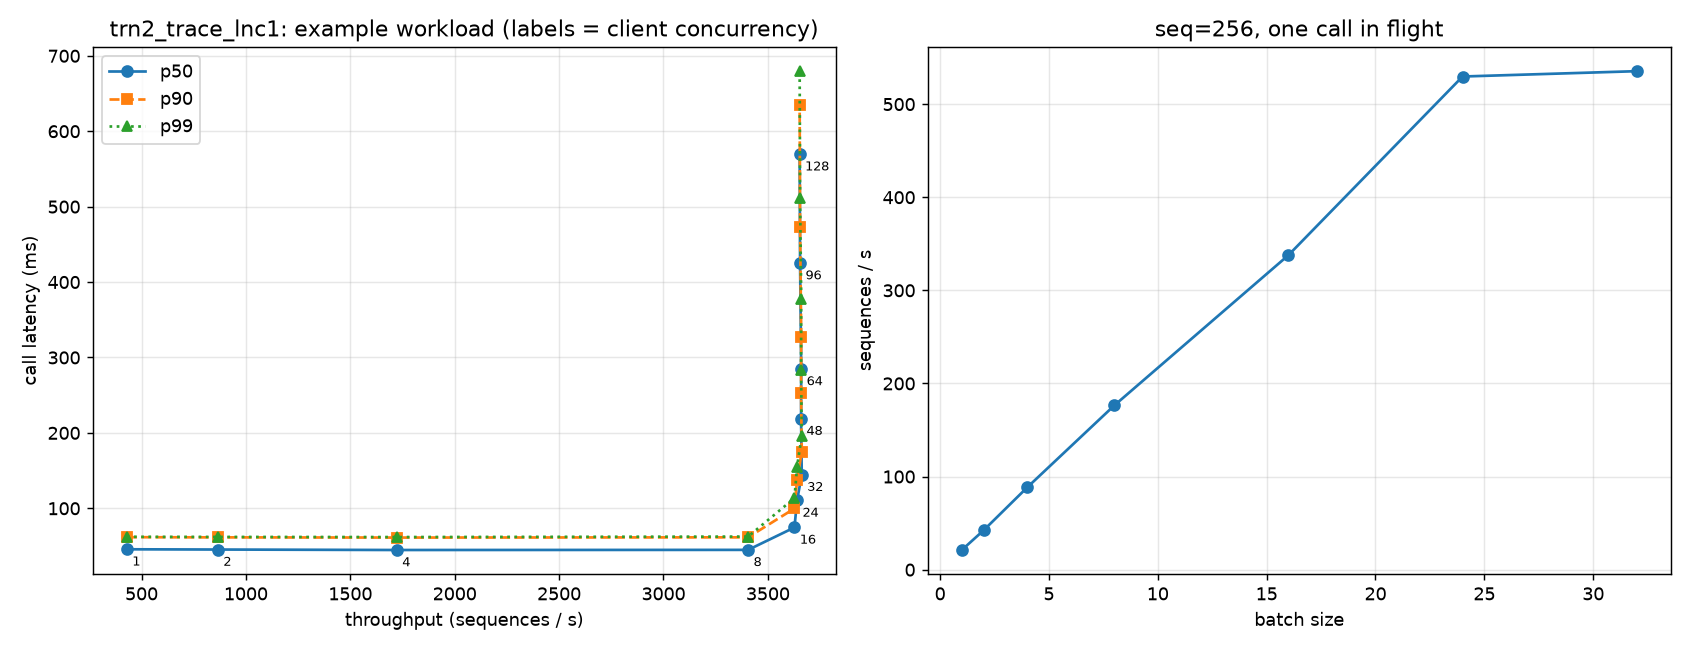

('triton-prodmix', '', 0)

In [8]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
res = {"tag": TAG, "platform": PLATFORM, "path": PATH, "lnc": LNC, "instances": NUM_INSTANCES,
       "example_mix": {str(L): {"pct_calls": v[0], "mean_seq_per_call": v[1]} for L, v in EXAMPLE_MIX.items()},
       "target_seq_pct": {str(L): round(v, 2) for L, v in TARGET_SEQ_PCT.items()},
       "buckets": BUCKETS, "curve": CURVE, "bs_sweep_256": BS_SWEEP,
       "accuracy": acc}
os.makedirs(f"{HOME}/prodmix_results", exist_ok=True)
json.dump(res, open(f"{HOME}/prodmix_results/{TAG}.json", "w"), indent=2)

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
x = [r["seq_per_s"] for r in CURVE]
for key, lbl, st in [("p50_ms", "p50", "-o"), ("p90_ms", "p90", "--s"), ("p99_ms", "p99", ":^")]:
    ax[0].plot(x, [r[key] for r in CURVE], st, label=lbl)
for r in CURVE:
    ax[0].annotate(str(r["concurrency"]), (r["seq_per_s"], r["p50_ms"]), fontsize=7,
                   xytext=(3, -9), textcoords="offset points")
ax[0].set_xlabel("throughput (sequences / s)"); ax[0].set_ylabel("call latency (ms)")
ax[0].set_title(f"{TAG}: example workload (labels = client concurrency)"); ax[0].grid(alpha=.3); ax[0].legend()
ax[1].plot([r["batch"] for r in BS_SWEEP], [r["seq_per_s"] for r in BS_SWEEP], "-o")
ax[1].set_xlabel("batch size"); ax[1].set_ylabel("sequences / s"); ax[1].grid(alpha=.3)
ax[1].set_title("seq=256, one call in flight")
plt.tight_layout()
png = f"{HOME}/prodmix_results/{TAG}.png"
plt.savefig(png, dpi=130)
print("wrote", png)
from IPython.display import Image, display
display(Image(png))
sh(["sudo", "docker", "rm", "-f", CONTAINER])